In [1]:
import requests
import configparser

In [158]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from utils import plot_image
import numpy as np
from rasterio.io import MemoryFile
import datetime

In [2]:

config_file = configparser.ConfigParser()
config_file.read("config.ini")

username = config_file["copernicus"]["username"]
password = config_file["copernicus"]["password"]

# Config file example:
# [copernicus]
# username = xyz@gmail.com
# password = 1234

In [25]:
def get_access_token(username: str, password: str) -> str:

    data = {
        "client_id": "cdse-public",
        "username": username,
        "password": password,
        "grant_type": "password",
    }

    try:
        r = requests.post(
            "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
            data=data,
        )
        r.raise_for_status()
        access_token = r.json().get("access_token")
        if not access_token:
            raise ValueError("No access token found in response.")
        return access_token
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None

# Retrieve the token
access_token = get_access_token(username, password)

In [100]:
## PARA IMAGEN

access_token = get_access_token(username, password)


In [223]:
start = datetime.datetime(2022, 7, 1).date().isoformat()

end = datetime.datetime(2022, 7, 20).date().isoformat()
print(start)
print(end)
time_interval = [start, end]

2022-07-01
2022-07-20


In [262]:
def get_image_copernicus(access_token, time_interval, image_type, evalscript): 
    identifier = ""
    if image_type == "png": 
        identifier = "default"
    elif image_type == "tiff":
        identifier = "index"
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"

    headers={
    "Content-Type": "application/json",
    "Authorization" : "Bearer "+ access_token
    }

    json={
        "input": {
            "bounds": {
                "bbox": [
                    -0.866977,
                    37.628916,
                    -0.71696,
                    37.822802
                    ]
            },
            "data": [
                {
                "dataFilter": {
                    "timeRange": {
                    "from": time_interval[0] + "T00:00:00Z", #"2024-10-12T00:00:00Z", #YYYY-mm-dd
                    "to": time_interval[1] + "T23:59:59Z"#"2024-11-12T23:59:59Z"
                    },
                    "mosaickingOrder": "leastCC"
                
                },
                "type": "sentinel-2-l2a"
                }]
        },
        "output": {
            "width": 1323,
            "height": 2158,

            "responses": [
                {
                    "identifier": identifier,
                    "format": {
                        "type": "image/" + image_type
                    }
                }
            ]
        },
        "evalscript" : evalscript
    }

    response = requests.post(url, headers=headers, json=json)

    if response.status_code == 200:
        print(f"Request completed")
        return response 
    else:
        print(f"Request failed {response.content}")
        return None


In [246]:
start = datetime.datetime(2024, 1, 1)
end = datetime.datetime(2024, 1, 31)
n_chunks = 3
tdelta = (end - start) / n_chunks
edges = [(start + i * tdelta).date().isoformat() for i in range(n_chunks+1)]
slots = [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]

In [232]:
access_token = get_access_token(username, password)
evalscript = """
    //VERSION=3

    function setup() {
        return {
            input: ["B03", "B08"],
            output: {
                id: "index",       // Identifier for the output
                bands: 1,
                sampleType: "FLOAT32"
            }
        }
    }

    function evaluatePixel(samples) {
        return [index(samples.B03, samples.B08)]
    }
    """
image_type = "tiff" # png para imagen / tiff para array - depende del evalscript
for time_interval in slots:
    response = get_image_copernicus(access_token, time_interval, image_type, evalscript)

Request completed
Request completed
Request completed


In [301]:
access_token = get_access_token(username, password)

evalscript = """
    //VERSION=3

    // CHANGE TO USE DIFFERENT INDEX
    // 0 = Chlorophyll a mg/m**3 | Range 0.9 - 28.1 | (https://custom-scripts.sentinel-hub.com/sentinel-2/mago_water_quality_monitoring_tool/) (Mishra 2012 Based on NDCI) 
    // 1 = Chlorophyll a for high values > 5 mg / m3 (Soria-Perpinyà 2021) | Range 5 - 675
    // 2 = Cyanobacteria (Phycocyanin) mg/m3 (Soria-Perpinyà 2021) | Range 0 - 1000
    // 3 = Turbidity NTU | Range 15 - 200
    // 4 = NDWI
    // 5 = NCDI (Normalized Difference Chlorophyll Index )
    // 6 = Chlorophyll a mg/m**3 (https://custom-scripts.sentinel-hub.com/sentinel-2/se2waq/)
    // 7 = NDVI

    var indexNumber = 7;
    
    // Change for range of the selected index. Adjust for higher or lower sensitivity after visual representation
    var minValue = -1;
    var maxValue = 1;

    
    // Color Scale
    var scaleLimits = [minValue, (maxValue + 3 * minValue) / 4, (maxValue + minValue) / 2, (3 * maxValue + minValue) / 4, maxValue] 
    // If min = 0  y max = 30: [0, 7.5, 15, 22.5, 30]. Points where color changes
    // For intermediate values colorBlend interpolates between the colors that surround the value
    var s = 255; 
    var colorScale =  // Colors mapped to  
    [
        [0 / s, 0 / s, 255 / s], // Blue
        [0 / s, 255 / s, 255 / s], // Cyan
        [0 / s, 255 / s, 0 / s], // Green
        [255 / s, 255 / s, 0 / s], // Yellow
        [255 / s, 0 / s, 0 / s], // Red
    ];
    var inverseColorScale =  // Inverse scale because for some indexes it makes more sense 
    [
        [255 / s, 0 / s, 0 / s], // Red
        [255 / s, 255 / s, 0 / s], // Yellow
        [0 / s, 255 / s, 0 / s], // Green
        [0 / s, 255 / s, 255 / s], // Cyan
        [0 / s, 0 / s, 255 / s], // Blue  
    ];


      
    function setup() {
        return {
            input: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "SCL", "dataMask"],
            output: [
                { id: "default", bands: 3 },
                { id: "index", bands: 1, sampleType: "FLOAT32" },
                { id: "dataMask", bands: 1 }
            ]
        }
    }

    function evaluatePixel(samples) {

        // Initizalize 
        let imgVals = null;
        let val = NaN;

        // Filter to color only over water bodes: if NDWI is lower than 0 is not water, so return true color
        let NDWI = index(samples.B03, samples.B08); 
        let TrueColor = [samples.B04 * 2.5, samples.B03 * 2.5, samples.B02 * 2.5]; // Factor 2.5 to increase brightness

        // Apply NDWI filter only over these indexNumber's
        const applyNDWIFilter = [0, 1, 2, 3, 4, 5, 6];

        // Indexes computed inside the switch no not all of them are calculated, only the one that we want
        if (applyNDWIFilter.includes(indexNumber) && NDWI < -0) { 
            imgVals = [...TrueColor, samples.dataMask]; // To get an array with R G B and mask to include validity information for eaxh pixel
        } else if (applyNDWIFilter.includes(indexNumber)) {
            switch (indexNumber) {
                case 0: 
                    let index0 = 14.039 + (86.11 * (samples.B05 - samples.B04) / (samples.B05 + samples.B04)) + (194.325 * Math.pow((samples.B05 - samples.B04) / (samples.B05 + samples.B04), 2));
                    let viz0 = colorBlend(index0, scaleLimits, colorScale);
                    imgVals = [...viz0, samples.dataMask];
                    val = index0;
                    break;
                case 1: 
                    let index1 = 19.866 * Math.pow(samples.B05 / samples.B04, 2.3051);
                    let viz1 = colorBlend(index1, scaleLimits, colorScale);
                    imgVals = [...viz1, samples.dataMask];
                    val = index1;
                    break;
                case 2: 
                    let index2 = 21.554 * Math.pow((samples.B05 / samples.B04), 3.47941);
                    let viz2 = colorBlend(index2, scaleLimits, colorScale);
                    imgVals = [...viz2, samples.dataMask];
                    val = index2;
                    break;
                case 3: 
                    let index3 = 194.79 * (samples.B05 * (samples.B05 / samples.B02)) + 0.9061;
                    let viz3 = colorBlend(index3, scaleLimits, colorScale);
                    imgVals = [...viz3, samples.dataMask];
                    val = index3;
                    break;
                case 4:
                    let index4 = index(samples.B03, samples.B08);
                    let viz4 = colorBlend(index4, scaleLimits, inverseColorScale);
                    imgVals = [...viz4, samples.dataMask];
                    val = index4;
                    break;
                case 5:
                    let index5 = index(samples.B05, samples.B04);
                    let viz5 = colorBlend(index5, scaleLimits, inverseColorScale);
                    imgVals = [...viz5, samples.dataMask];
                    val = index5;
                    break;
                case 6: 
                    let index6 = 4.26 * Math.pow(samples.B03/samples.B01, 3.94);
                    let viz6 = colorBlend(index6, scaleLimits, colorScale);
                    imgVals = [...viz6, samples.dataMask];
                    val = index6;
                    break;
        }
        } else {
            switch (indexNumber) {
                case 7: 
                    let index7 = index(samples.B08, samples.B04);
                    let viz7 = colorBlend(index7, scaleLimits, inverseColorScale);
                    imgVals = [...viz7, samples.dataMask];
                    val = index7;
                    break;
            }
        }

        const indexVal = samples.dataMask === 1 ? val : NaN; // If the pixel is valid (dataMask = 1), value set as the val previously computed, if not, NaN to ignore the pixel

        return {
            default: imgVals,
            index: [indexVal],
            // eobrowserStats: [val, isCloud(samples.SCL) ? 1 : 0], // Add function isCloud si se va a dejar
            dataMask: [samples.dataMask]
        };
    }
    """
image_type = "png" # png para imagen / tiff para array - depende del evalscript
start = datetime.datetime(2022, 7, 1).date().isoformat()
end = datetime.datetime(2022, 7, 20).date().isoformat()
time_interval = [start, end]
response = get_image_copernicus(access_token, time_interval, image_type, evalscript)

Request completed


In [277]:
if response.status_code == 200:
    # Open the TIFF data directly from the response content using a MemoryFile
    with MemoryFile(response.content) as memfile:
        with memfile.open() as src:
            index_array = src.read(1)  # Read the first band as a NumPy array

    # Now `index_array` is a NumPy array containing the index values for each pixel
    print(index_array)
else:
    print(f"Request failed with status code: {response.status_code}")

[[192 200 194 ...   0   0   0]
 [153 177 190 ...   0   0   0]
 [108 171 189 ...   0   0   0]
 ...
 [169 194 174 ...  84  74  51]
 [130 151 128 ...  81  57  50]
 [ 99  97  95 ...  78  60  50]]


/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/rasterio/io.py:138: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  return DatasetReader(mempath, driver=driver, sharing=sharing, **kwargs)


In [302]:
index_array.shape

(2158, 1323)

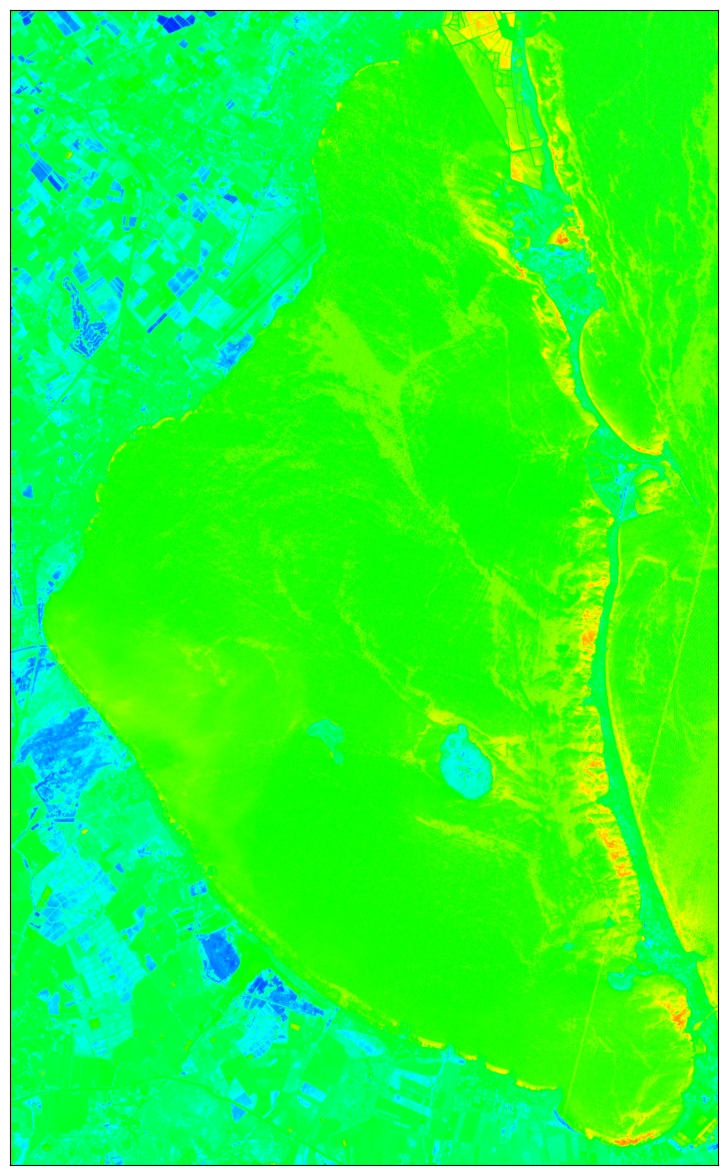

In [303]:
image = Image.open(BytesIO(response.content))
image_np = np.array(image, dtype=np.float32)  # Convert to float for scaling

# Use your `plot_image` function with a brightness factor and clipping range
plot_image(image_np, factor=1 / 255, clip_range=(-1, 1))